# spaCy Basics: Industrial-Strength Natural Language Processing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vuhung16au/nlp-learning-journey/blob/main/examples/spacy-basic.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/vuhung16au/nlp-learning-journey/blob/main/examples/spacy-basic.ipynb)
[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/vuhung16au/nlp-learning-journey/blob/main/examples/spacy-basic.ipynb)

## Overview

spaCy is a free, open-source library for advanced Natural Language Processing (NLP) in Python. It's designed specifically for production use and helps you build applications that process and understand large volumes of text.

## What You'll Learn

- Setting up spaCy and loading language models
- Core spaCy concepts: Documents, Tokens, and Spans
- Tokenization and sentence segmentation
- Part-of-speech tagging and linguistic attributes
- Named entity recognition (NER)
- Dependency parsing and syntactic analysis
- Lemmatization and morphological analysis
- Word vectors and semantic similarity
- Vietnamese/English text processing examples

## Prerequisites

Basic understanding of Python and natural language processing concepts.

## Setup and Installation

Let's install the required libraries and download the spaCy English model.

In [1]:
# Environment Detection and Setup (Required for all notebooks in this repository)
import sys
import subprocess
import os
import time

# Detect the runtime environment
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

print(f"Environment detected:")
print(f"  - Local: {IS_LOCAL}")
print(f"  - Google Colab: {IS_COLAB}")
print(f"  - Kaggle: {IS_KAGGLE}")

# Platform-specific system setup
if IS_COLAB:
    print("\nSetting up Google Colab environment...")
    !apt update -qq
    !apt install -y -qq libpq-dev
elif IS_KAGGLE:
    print("\nSetting up Kaggle environment...")
    # Kaggle usually has most packages pre-installed
else:
    print("\nSetting up local environment...")

# Install required packages for this notebook
required_packages = [
    "spacy",
    "pandas",
    "matplotlib",
    "seaborn"
]

print("\nInstalling required packages...")
for package in required_packages:
    if IS_COLAB or IS_KAGGLE:
        !pip install -q {package}
    else:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package],
                      capture_output=True)
    print(f"✓ {package}")

# Download spaCy model
print("\nDownloading spaCy English model...")
try:
    if IS_COLAB or IS_KAGGLE:
        !python -m spacy download en_core_web_sm
    else:
        subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
                      capture_output=True)
    print("✓ spaCy model downloaded successfully")
except Exception as e:
    print(f"⚠️  spaCy model download failed: {e}")

print("\n🎉 Environment setup complete!")

Environment detected:
  - Local: False
  - Google Colab: True
  - Kaggle: False

Setting up Google Colab environment...
44 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
libpq-dev is already the newest version (14.19-0ubuntu0.22.04.1).
libpq-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 44 not upgraded.

Installing required packages...
✓ spacy
✓ pandas
✓ matplotlib
✓ seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 88.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart 

In [2]:
# Import required libraries
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the English language model
nlp = spacy.load("en_core_web_sm")

print("✓ Libraries imported successfully")
print(f"✓ spaCy version: {spacy.__version__}")
print(f"✓ Model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

✓ Libraries imported successfully
✓ spaCy version: 3.8.7
✓ Model loaded: core_web_sm v3.8.0


## 1. Basic spaCy Concepts

spaCy processes text through three main object types:
- **Doc**: A sequence of tokens (the processed text)
- **Token**: An individual word, punctuation mark, whitespace, etc.
- **Span**: A slice of a Doc object

In [3]:
# Process text with spaCy
text = "Hello world! My name is John and I love programming."
doc = nlp(text)

print(f"Original text: {text}")
print(f"Doc object: {doc}")
print(f"Number of tokens: {len(doc)}")
print("\nTokens:")
for i, token in enumerate(doc):
    print(f"  {i}: '{token.text}'")

Original text: Hello world! My name is John and I love programming.
Doc object: Hello world! My name is John and I love programming.
Number of tokens: 12

Tokens:
  0: 'Hello'
  1: 'world'
  2: '!'
  3: 'My'
  4: 'name'
  5: 'is'
  6: 'John'
  7: 'and'
  8: 'I'
  9: 'love'
  10: 'programming'
  11: '.'


## 2. Tokenization and Sentence Segmentation

spaCy automatically tokenizes text and segments it into sentences using sophisticated linguistic rules.

In [4]:
# Example with multiple sentences and complex punctuation
complex_text = "Dr. Smith went to the U.S.A. yesterday. He bought a $50 gift for his friend! Isn't that nice?"
doc = nlp(complex_text)

print("=== TOKENIZATION ===")
print(f"Text: {complex_text}")
print(f"\nTokens ({len(doc)} total):")
for token in doc:
    print(f"  '{token.text}' | Whitespace after: {repr(token.whitespace_)}")

print("\n=== SENTENCE SEGMENTATION ===")
sentences = list(doc.sents)
print(f"Number of sentences: {len(sentences)}")
for i, sent in enumerate(sentences, 1):
    print(f"  Sentence {i}: {sent.text}")

=== TOKENIZATION ===
Text: Dr. Smith went to the U.S.A. yesterday. He bought a $50 gift for his friend! Isn't that nice?

Tokens (23 total):
  'Dr.' | Whitespace after: ' '
  'Smith' | Whitespace after: ' '
  'went' | Whitespace after: ' '
  'to' | Whitespace after: ' '
  'the' | Whitespace after: ' '
  'U.S.A.' | Whitespace after: ' '
  'yesterday' | Whitespace after: ''
  '.' | Whitespace after: ' '
  'He' | Whitespace after: ' '
  'bought' | Whitespace after: ' '
  'a' | Whitespace after: ' '
  '$' | Whitespace after: ''
  '50' | Whitespace after: ' '
  'gift' | Whitespace after: ' '
  'for' | Whitespace after: ' '
  'his' | Whitespace after: ' '
  'friend' | Whitespace after: ''
  '!' | Whitespace after: ' '
  'Is' | Whitespace after: ''
  'n't' | Whitespace after: ' '
  'that' | Whitespace after: ' '
  'nice' | Whitespace after: ''
  '?' | Whitespace after: ''

=== SENTENCE SEGMENTATION ===
Number of sentences: 3
  Sentence 1: Dr. Smith went to the U.S.A. yesterday.
  Sentence 2: 

## 3. Part-of-Speech Tagging and Linguistic Attributes

spaCy provides detailed linguistic information for each token, including part-of-speech tags, morphological features, and more.

In [5]:
# Vietnamese/English translation example
english_text = "My name is John and I love programming."
vietnamese_text = "Tên tôi là John và tôi yêu lập trình."

print("=== ENGLISH TEXT ANALYSIS ===")
doc_en = nlp(english_text)
print(f"Text: {english_text}")
print(f"\n{'Token':<12} {'Lemma':<12} {'POS':<6} {'Tag':<6} {'Stop?':<5} {'Alpha?':<6}")
print("-" * 55)
for token in doc_en:
    print(f"{token.text:<12} {token.lemma_:<12} {token.pos_:<6} {token.tag_:<6} {token.is_stop:<5} {token.is_alpha:<6}")

print("\n=== VIETNAMESE TEXT (Basic Processing) ===")
# Note: spaCy's English model can still process Vietnamese text for basic tokenization
doc_vi = nlp(vietnamese_text)
print(f"Text: {vietnamese_text}")
print(f"\n{'Token':<12} {'POS':<6} {'Alpha?':<6}")
print("-" * 26)
for token in doc_vi:
    print(f"{token.text:<12} {token.pos_:<6} {token.is_alpha:<6}")

=== ENGLISH TEXT ANALYSIS ===
Text: My name is John and I love programming.

Token        Lemma        POS    Tag    Stop? Alpha?
-------------------------------------------------------
My           my           PRON   PRP$   1     1     
name         name         NOUN   NN     1     1     
is           be           AUX    VBZ    1     1     
John         John         PROPN  NNP    0     1     
and          and          CCONJ  CC     1     1     
I            I            PRON   PRP    1     1     
love         love         VERB   VBP    0     1     
programming  programming  NOUN   NN     0     1     
.            .            PUNCT  .      0     0     

=== VIETNAMESE TEXT (Basic Processing) ===
Text: Tên tôi là John và tôi yêu lập trình.

Token        POS    Alpha?
--------------------------
Tên          PROPN  1     
tôi          NOUN   1     
là           ADP    1     
John         PROPN  1     
và           PROPN  1     
tôi          PROPN  1     
yêu          PROPN  1     
lập  

## 4. Named Entity Recognition (NER)

spaCy can automatically identify and classify named entities in text, such as people, organizations, locations, and more.

In [6]:
# Text with various named entities
text_with_entities = "Apple Inc. was founded by Steve Jobs in Cupertino, California on April 1, 1976. The company is worth over $2 trillion today."
doc = nlp(text_with_entities)

print("=== NAMED ENTITY RECOGNITION ===")
print(f"Text: {text_with_entities}")
print(f"\n{'Entity':<20} {'Label':<12} {'Description':<30}")
print("-" * 65)

for ent in doc.ents:
    print(f"{ent.text:<20} {ent.label_:<12} {spacy.explain(ent.label_):<30}")

# Vietnamese/English example with entities
print("\n=== BILINGUAL EXAMPLE ===")
bilingual_text = "John lives in Vietnam and works for Microsoft. Tên anh ấy là John."
doc_bilingual = nlp(bilingual_text)

print(f"Text: {bilingual_text}")
print("\nDetected entities:")
for ent in doc_bilingual.ents:
    print(f"  {ent.text} -> {ent.label_} ({spacy.explain(ent.label_)})")

=== NAMED ENTITY RECOGNITION ===
Text: Apple Inc. was founded by Steve Jobs in Cupertino, California on April 1, 1976. The company is worth over $2 trillion today.

Entity               Label        Description                   
-----------------------------------------------------------------
Apple Inc.           ORG          Companies, agencies, institutions, etc.
Steve Jobs           PERSON       People, including fictional   
Cupertino            GPE          Countries, cities, states     
California           GPE          Countries, cities, states     
April 1, 1976        DATE         Absolute or relative dates or periods
over $2 trillion     MONEY        Monetary values, including unit
today                DATE         Absolute or relative dates or periods

=== BILINGUAL EXAMPLE ===
Text: John lives in Vietnam and works for Microsoft. Tên anh ấy là John.

Detected entities:
  John -> PERSON (People, including fictional)
  Vietnam -> GPE (Countries, cities, states)
  Microsoft -

## 5. Dependency Parsing

spaCy analyzes the grammatical structure of sentences, showing how words relate to each other.

In [7]:
# Simple sentence for dependency parsing
sentence = "The cat sat on the mat."
doc = nlp(sentence)

print("=== DEPENDENCY PARSING ===")
print(f"Sentence: {sentence}")
print(f"\n{'Token':<8} {'Dependency':<12} {'Head':<8} {'Children':<20}")
print("-" * 55)

for token in doc:
    children = [child.text for child in token.children]
    print(f"{token.text:<8} {token.dep_:<12} {token.head.text:<8} {', '.join(children):<20}")

print("\n=== DEPENDENCY RELATIONS ===")
for token in doc:
    print(f"{token.text} --{token.dep_}--> {token.head.text}")

=== DEPENDENCY PARSING ===
Sentence: The cat sat on the mat.

Token    Dependency   Head     Children            
-------------------------------------------------------
The      det          cat                          
cat      nsubj        sat      The                 
sat      ROOT         sat      cat, on, .          
on       prep         sat      mat                 
the      det          mat                          
mat      pobj         on       the                 
.        punct        sat                          

=== DEPENDENCY RELATIONS ===
The --det--> cat
cat --nsubj--> sat
sat --ROOT--> sat
on --prep--> sat
the --det--> mat
mat --pobj--> on
. --punct--> sat


## 6. Lemmatization and Morphological Analysis

spaCy can reduce words to their base forms (lemmas) and analyze their morphological features.

In [8]:
# Text with various word forms
text_forms = "The children were running quickly to their cars. They had been studying for hours."
doc = nlp(text_forms)

print("=== LEMMATIZATION ===")
print(f"Text: {text_forms}")
print(f"\n{'Token':<12} {'Lemma':<12} {'POS':<8} {'Morphology':<20}")
print("-" * 60)

for token in doc:
    if token.is_alpha:  # Only show alphabetic tokens
        morph = str(token.morph) if token.morph else "-"
        print(f"{token.text:<12} {token.lemma_:<12} {token.pos_:<8} {morph:<20}")

# Vietnamese/English lemmatization comparison
print("\n=== BILINGUAL LEMMATIZATION ===")
english_examples = ["running", "better", "mice", "children"]
vietnamese_examples = ["chạy", "tốt hơn", "chuột", "trẻ em"]

print("English:")
for word in english_examples:
    doc_word = nlp(word)
    token = doc_word[0]
    print(f"  {word} -> {token.lemma_}")

print("\nVietnamese (basic processing):")
for word in vietnamese_examples:
    doc_word = nlp(word)
    token = doc_word[0]
    print(f"  {word} -> {token.lemma_} (limited analysis with EN model)")

=== LEMMATIZATION ===
Text: The children were running quickly to their cars. They had been studying for hours.

Token        Lemma        POS      Morphology          
------------------------------------------------------------
The          the          DET      Definite=Def|PronType=Art
children     child        NOUN     Number=Plur         
were         be           AUX      Mood=Ind|Tense=Past|VerbForm=Fin
running      run          VERB     Aspect=Prog|Tense=Pres|VerbForm=Part
quickly      quickly      ADV      -                   
to           to           ADP      -                   
their        their        PRON     Number=Plur|Person=3|Poss=Yes|PronType=Prs
cars         car          NOUN     Number=Plur         
They         they         PRON     Case=Nom|Number=Plur|Person=3|PronType=Prs
had          have         AUX      Tense=Past|VerbForm=Fin
been         be           AUX      Tense=Past|VerbForm=Part
studying     study        VERB     Aspect=Prog|Tense=Pres|VerbForm=Part

## 7. Word Vectors and Semantic Similarity

spaCy includes word vectors that capture semantic meaning, allowing you to compute similarity between words and texts.

In [9]:
# Check if the model has word vectors
print(f"Model has word vectors: {nlp.meta.get('vectors', {}).get('keys', 0) > 0}")
print(f"Vector dimensions: {nlp.meta.get('vectors', {}).get('width', 'N/A')}")

# Word similarity examples
print("\n=== WORD SIMILARITY ===")
words = ["cat", "dog", "car", "programming", "computer"]
docs = [nlp(word) for word in words]

print("Similarity matrix:")
print(f"{'':>12}", end="")
for word in words:
    print(f"{word:>8}", end="")
print()

for i, word1 in enumerate(words):
    print(f"{word1:>12}", end="")
    for j, word2 in enumerate(words):
        if docs[i].vector_norm and docs[j].vector_norm:  # Check if vectors exist
            similarity = docs[i].similarity(docs[j])
            print(f"{similarity:>8.3f}", end="")
        else:
            print(f"{'N/A':>8}", end="")
    print()

# Vietnamese/English word comparison
print("\n=== BILINGUAL SIMILARITY EXAMPLE ===")
# Note: Limited accuracy with English model on Vietnamese
english_words = ["love", "programming", "computer"]
vietnamese_words = ["yêu", "lập trình", "máy tính"]

print("English words similarity:")
en_docs = [nlp(word) for word in english_words]
for i in range(len(english_words)):
    for j in range(i+1, len(english_words)):
        if en_docs[i].vector_norm and en_docs[j].vector_norm:
            sim = en_docs[i].similarity(en_docs[j])
            print(f"  {english_words[i]} <-> {english_words[j]}: {sim:.3f}")

print("\nVietnamese translation pairs:")
for en, vi in zip(english_words, vietnamese_words):
    print(f"  {en} -> {vi}")

Model has word vectors: False
Vector dimensions: 0

=== WORD SIMILARITY ===
Similarity matrix:
                 cat     dog     carprogrammingcomputer
         cat   1.000   0.742   0.576   0.598   0.730
         dog   0.742   1.000   0.685   0.643   0.789
         car   0.576   0.685   1.000   0.561   0.761
 programming   0.598   0.643   0.561   1.000   0.705
    computer   0.730   0.789   0.761   0.705   1.000

=== BILINGUAL SIMILARITY EXAMPLE ===
English words similarity:
  love <-> programming: 0.648
  love <-> computer: 0.582
  programming <-> computer: 0.705

Vietnamese translation pairs:
  love -> yêu
  programming -> lập trình
  computer -> máy tính


/tmp/ipython-input-3522992636.py:20: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  similarity = docs[i].similarity(docs[j])
/tmp/ipython-input-3522992636.py:37: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the l

## 8. Practical Example: Text Analysis Pipeline

Let's combine multiple spaCy features to analyze a piece of text comprehensively.

In [10]:
def analyze_text(text):
    """
    Comprehensive text analysis using spaCy
    """
    doc = nlp(text)

    analysis = {
        'text': text,
        'tokens': len(doc),
        'sentences': len(list(doc.sents)),
        'entities': [(ent.text, ent.label_) for ent in doc.ents],
        'pos_counts': Counter([token.pos_ for token in doc if token.is_alpha]),
        'lemmas': [token.lemma_ for token in doc if token.is_alpha and not token.is_stop],
        'stop_words': [token.text for token in doc if token.is_stop]
    }

    return analysis

# Analyze sample texts
sample_texts = [
    "Apple Inc. was founded by Steve Jobs in California. The company revolutionized personal computing.",
    "Machine learning and artificial intelligence are transforming how we process natural language."
]

for i, text in enumerate(sample_texts, 1):
    print(f"=== ANALYSIS {i} ===")
    analysis = analyze_text(text)

    print(f"Text: {analysis['text']}")
    print(f"Tokens: {analysis['tokens']} | Sentences: {analysis['sentences']}")

    print(f"\nEntities: {len(analysis['entities'])}")
    for entity, label in analysis['entities']:
        print(f"  {entity} ({label})")

    print(f"\nPOS Distribution:")
    for pos, count in analysis['pos_counts'].most_common():
        print(f"  {pos}: {count}")

    print(f"\nKey Lemmas: {', '.join(analysis['lemmas'][:10])}")
    print(f"Stop Words: {', '.join(analysis['stop_words'])}")
    print()

=== ANALYSIS 1 ===
Text: Apple Inc. was founded by Steve Jobs in California. The company revolutionized personal computing.
Tokens: 16 | Sentences: 2

Entities: 3
  Apple Inc. (ORG)
  Steve Jobs (PERSON)
  California (GPE)

POS Distribution:
  PROPN: 4
  VERB: 2
  ADP: 2
  NOUN: 2
  AUX: 1
  DET: 1
  ADJ: 1

Key Lemmas: Apple, found, Steve, Jobs, California, company, revolutionize, personal, computing
Stop Words: was, by, in, The

=== ANALYSIS 2 ===
Text: Machine learning and artificial intelligence are transforming how we process natural language.
Tokens: 13 | Sentences: 1

Entities: 0

POS Distribution:
  NOUN: 4
  ADJ: 2
  VERB: 2
  CCONJ: 1
  AUX: 1
  SCONJ: 1
  PRON: 1

Key Lemmas: machine, learning, artificial, intelligence, transform, process, natural, language
Stop Words: and, are, how, we



## 9. Vietnamese/English Processing Examples

Demonstrating basic processing of Vietnamese text alongside English, following the repository's bilingual focus.

In [11]:
# Translation pairs as used throughout the repository
translation_pairs = [
    ("My name is", "Tên tôi là"),
    ("Hello", "Xin chào"),
    ("Thank you", "Cảm ơn"),
    ("How are you?", "Bạn khỏe không?"),
    ("I love programming", "Tôi yêu lập trình")
]

print("=== BILINGUAL TEXT PROCESSING ===")
print("Processing English and Vietnamese text with spaCy (English model)")
print()

for english, vietnamese in translation_pairs:
    print(f"English: {english}")
    print(f"Vietnamese: {vietnamese}")

    # Process both texts
    doc_en = nlp(english)
    doc_vi = nlp(vietnamese)

    print(f"  EN tokens: {[token.text for token in doc_en]}")
    print(f"  VI tokens: {[token.text for token in doc_vi]}")

    # Basic linguistic analysis
    en_pos = [f"{token.text}({token.pos_})" for token in doc_en if token.is_alpha]
    vi_pos = [f"{token.text}({token.pos_})" for token in doc_vi if token.is_alpha]

    print(f"  EN POS: {' '.join(en_pos)}")
    print(f"  VI POS: {' '.join(vi_pos)} (limited accuracy)")
    print("-" * 50)

print("\nNote: Vietnamese analysis is limited when using the English spaCy model.")
print("For full Vietnamese NLP support, consider using Vietnamese-specific models.")

=== BILINGUAL TEXT PROCESSING ===
Processing English and Vietnamese text with spaCy (English model)

English: My name is
Vietnamese: Tên tôi là
  EN tokens: ['My', 'name', 'is']
  VI tokens: ['Tên', 'tôi', 'là']
  EN POS: My(PRON) name(NOUN) is(AUX)
  VI POS: Tên(PROPN) tôi(NOUN) là(ADP) (limited accuracy)
--------------------------------------------------
English: Hello
Vietnamese: Xin chào
  EN tokens: ['Hello']
  VI tokens: ['Xin', 'chào']
  EN POS: Hello(INTJ)
  VI POS: Xin(PROPN) chào(NOUN) (limited accuracy)
--------------------------------------------------
English: Thank you
Vietnamese: Cảm ơn
  EN tokens: ['Thank', 'you']
  VI tokens: ['Cảm', 'ơn']
  EN POS: Thank(VERB) you(PRON)
  VI POS: Cảm(PROPN) ơn(PROPN) (limited accuracy)
--------------------------------------------------
English: How are you?
Vietnamese: Bạn khỏe không?
  EN tokens: ['How', 'are', 'you', '?']
  VI tokens: ['Bạn', 'khỏe', 'không', '?']
  EN POS: How(SCONJ) are(AUX) you(PRON)
  VI POS: Bạn(NOUN) khỏe(ADJ

## 10. Simple Visualization

Basic visualization of spaCy analysis results.

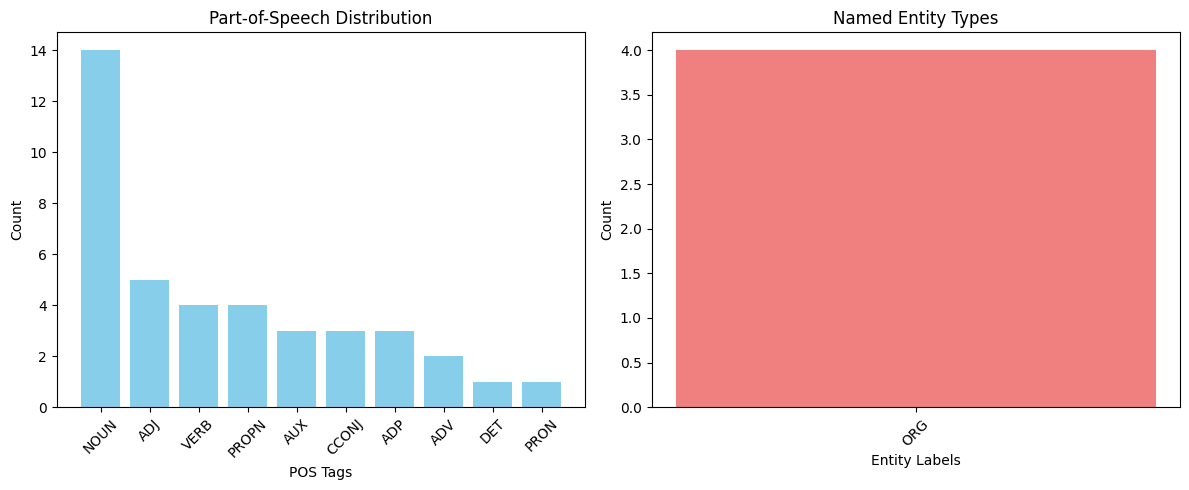

=== TEXT ANALYSIS SUMMARY ===
Text length: 315 characters
Tokens: 50
Sentences: 3

Detected entities:
  Google -> ORG (Companies, agencies, institutions, etc.)
  Microsoft -> ORG (Companies, agencies, institutions, etc.)
  Apple -> ORG (Companies, agencies, institutions, etc.)
  NLP -> ORG (Companies, agencies, institutions, etc.)


In [12]:
# Analyze a longer text for visualization
sample_text = """
Natural language processing is a fascinating field that combines linguistics, computer science,
and artificial intelligence. Companies like Google, Microsoft, and Apple are investing heavily
in NLP technologies. Machine learning algorithms can now understand and generate human language
with remarkable accuracy.
""".strip()

doc = nlp(sample_text)

# POS tag distribution
pos_counts = Counter([token.pos_ for token in doc if token.is_alpha])

plt.figure(figsize=(12, 5))

# Plot 1: POS distribution
plt.subplot(1, 2, 1)
pos_labels, pos_values = zip(*pos_counts.most_common())
plt.bar(pos_labels, pos_values, color='skyblue')
plt.title('Part-of-Speech Distribution')
plt.xlabel('POS Tags')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot 2: Entity types
plt.subplot(1, 2, 2)
entity_counts = Counter([ent.label_ for ent in doc.ents])
if entity_counts:
    ent_labels, ent_values = zip(*entity_counts.most_common())
    plt.bar(ent_labels, ent_values, color='lightcoral')
    plt.title('Named Entity Types')
    plt.xlabel('Entity Labels')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'No entities found', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Named Entity Types')

plt.tight_layout()
plt.show()

# Print detailed results
print("=== TEXT ANALYSIS SUMMARY ===")
print(f"Text length: {len(sample_text)} characters")
print(f"Tokens: {len(doc)}")
print(f"Sentences: {len(list(doc.sents))}")
print(f"\nDetected entities:")
for ent in doc.ents:
    print(f"  {ent.text} -> {ent.label_} ({spacy.explain(ent.label_)})")

## Summary

In this notebook, we've explored the core features of spaCy:

### Key spaCy Features Covered:
1. **Document Processing**: Creating Doc objects from text
2. **Tokenization**: Splitting text into meaningful units
3. **Sentence Segmentation**: Identifying sentence boundaries
4. **Part-of-Speech Tagging**: Grammatical category assignment
5. **Named Entity Recognition**: Identifying people, places, organizations
6. **Dependency Parsing**: Understanding grammatical relationships
7. **Lemmatization**: Reducing words to their base forms
8. **Word Vectors**: Semantic similarity computation

### Vietnamese/English Examples:
- Demonstrated bilingual text processing capabilities
- Showed translation pairs commonly used in the repository
- Highlighted limitations when using English models for Vietnamese text

### Next Steps:
- Explore spaCy's rule-based matching capabilities
- Learn about custom pipeline components
- Try spaCy with different language models
- Integrate spaCy with machine learning workflows

### Further Reading:
- [spaCy Official Documentation](https://spacy.io/)
- [spaCy Linguistic Features](https://spacy.io/usage/linguistic-features)
- [spaCy Models & Languages](https://spacy.io/models)
- [Advanced spaCy Usage](https://spacy.io/usage/processing-pipelines)